##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

from svipy.normflow import inverseAutoRegressiveFlow, maskedAutoRegressiveFlow, normFlowSequential, normFlowPriorNormal
from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


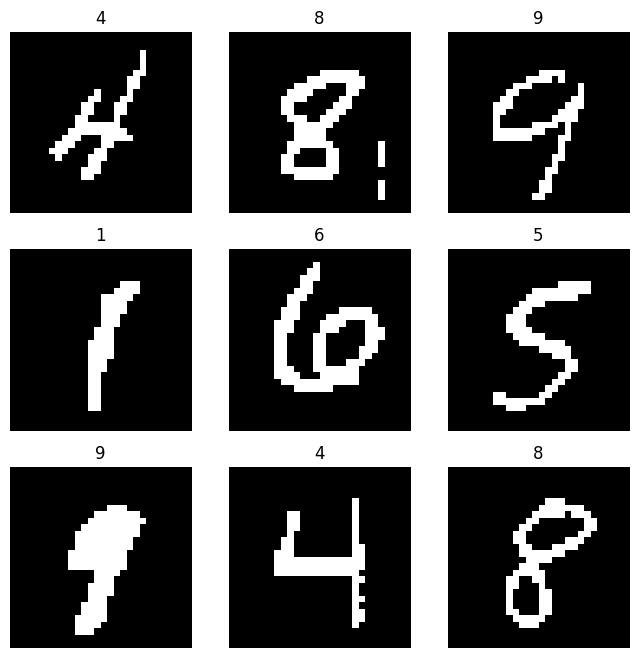

In [4]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(torch.argmax(label, dim=0).item()))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


In [6]:
def activeUnits(model, dataset, threshold=0.01, batchSize=256, device=device):
    """
    Burda et al.'s "active units" statistic: Var_x[mu(x)] per latent
    dimension, computed across the dataset. A dimension whose posterior
    mean barely moves across different inputs is \"dead\" -- carrying no
    information about x, regardless of what its logVar looks like.
    """
    
    model.eval()
    loader = DataLoader(dataset, batch_size=batchSize, shuffle=False)
    means = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            zMean, _ = model.encode(data)
            means.append(zMean.cpu())
    means = torch.cat(means, dim=0)
    
    variance = means.var(dim=0)
    nActive = 0
    for i, v in enumerate(variance):
        active = v.item() > threshold
        nActive += active
        print(f"dim {i}: Var_x[mu] = {v.item():.6f}  ({'active' if active else 'DEAD'})")
    
    print(f"{nActive}/{len(variance)} active units (threshold={threshold})")          
    return variance

##### VAEs with norm flows

In [7]:
class sumBceDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

###### Masked autoregressive flows

In [8]:
in_dims = 28 * 28
hid_dims = 16

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

prior = normFlowPriorNormal(normFlowSequential(OrderedDict([('maf1', maskedAutoRegressiveFlow([16, 256, 256])),
                                                            ('maf2', maskedAutoRegressiveFlow([16, 256, 256])),
                                                            ('maf3', maskedAutoRegressiveFlow([16, 256, 256]))
                                                           ])), hid_dims)

model_vae_maf = variationalAutoencoder(encoder, decoder, prior=prior).to(device)

In [9]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_maf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [10]:
%%time 
model_vae_maf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_maf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 199.906189 reconLoss: 198.437347 klLoss: 1.468836[12800/60000]
totalLoss: 204.566483 reconLoss: 202.664062 klLoss: 1.902413[25600/60000]
totalLoss: 188.882858 reconLoss: 185.861343 klLoss: 3.021508[38400/60000]
totalLoss: 179.869324 reconLoss: 175.947601 klLoss: 3.921716[51200/60000]
Validation Error: 174.803646
Epoch 2
-------------------------------
totalLoss: 166.577621 reconLoss: 159.854691 klLoss: 6.722924[12800/60000]
totalLoss: 158.253525 reconLoss: 150.339722 klLoss: 7.913802[25600/60000]
totalLoss: 141.089127 reconLoss: 132.086395 klLoss: 9.002730[38400/60000]
totalLoss: 143.534454 reconLoss: 133.915649 klLoss: 9.618803[51200/60000]
Validation Error: 138.904576
Epoch 3
-------------------------------
totalLoss: 136.597336 reconLoss: 125.004128 klLoss: 11.593214[12800/60000]
totalLoss: 135.417801 reconLoss: 124.194717 klLoss: 11.223088[25600/60000]
totalLoss: 127.682770 reconLoss: 116.185562 klLoss: 11.497204[38400/60000]
total

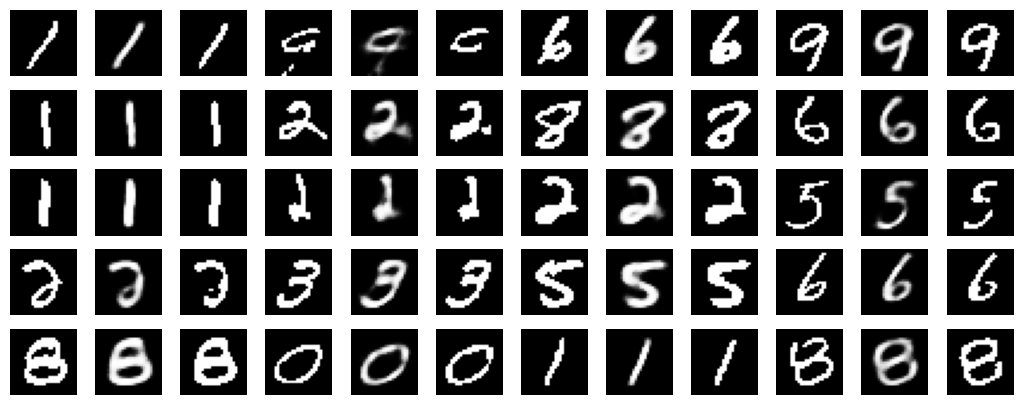

In [11]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_maf.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_maf.decode(model_vae_maf.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [12]:
activeUnits(model_vae_maf, trainImageData)

dim 0: Var_x[mu] = 24.363865  (active)
dim 1: Var_x[mu] = 17.260576  (active)
dim 2: Var_x[mu] = 17.650320  (active)
dim 3: Var_x[mu] = 16.284912  (active)
dim 4: Var_x[mu] = 23.367662  (active)
dim 5: Var_x[mu] = 15.821187  (active)
dim 6: Var_x[mu] = 14.788507  (active)
dim 7: Var_x[mu] = 15.342766  (active)
dim 8: Var_x[mu] = 19.728714  (active)
dim 9: Var_x[mu] = 28.337650  (active)
dim 10: Var_x[mu] = 18.991003  (active)
dim 11: Var_x[mu] = 37.121525  (active)
dim 12: Var_x[mu] = 12.716332  (active)
dim 13: Var_x[mu] = 15.236170  (active)
dim 14: Var_x[mu] = 37.426056  (active)
dim 15: Var_x[mu] = 11.545673  (active)
16/16 active units (threshold=0.01)


tensor([24.3639, 17.2606, 17.6503, 16.2849, 23.3677, 15.8212, 14.7885, 15.3428,
        19.7287, 28.3377, 18.9910, 37.1215, 12.7163, 15.2362, 37.4261, 11.5457])

###### Inverse Autoregressive Flows

In [13]:
in_dims = 28 * 28
hid_dims = 16

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)


prior = normFlowPriorNormal(normFlowSequential(OrderedDict([('iaf1', inverseAutoRegressiveFlow([16, 16, 16])),
                                                            ('iaf2', inverseAutoRegressiveFlow([16, 16, 16])),
                                                            # ('iaf3', inverseAutoRegressiveFlow([16, 256, 256]))
                                                           ])), hid_dims)

model_vae_iaf = variationalAutoencoder(encoder, decoder, prior=prior).to(device)

In [14]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_iaf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [15]:
%%time 
model_vae_iaf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_iaf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 203.883575 reconLoss: 201.790878 klLoss: 2.092698[12800/60000]
totalLoss: 195.650604 reconLoss: 193.406097 klLoss: 2.244499[25600/60000]
totalLoss: 189.714066 reconLoss: 186.788376 klLoss: 2.925683[38400/60000]
totalLoss: 190.508972 reconLoss: 185.328568 klLoss: 5.180401[51200/60000]
Validation Error: 171.150688
Epoch 2
-------------------------------
totalLoss: 157.389999 reconLoss: 149.574341 klLoss: 7.815658[12800/60000]
totalLoss: 155.649246 reconLoss: 147.044830 klLoss: 8.604422[25600/60000]
totalLoss: 146.946411 reconLoss: 137.104279 klLoss: 9.842128[38400/60000]
totalLoss: 145.140884 reconLoss: 134.731613 klLoss: 10.409273[51200/60000]
Validation Error: 141.506754
Epoch 3
-------------------------------
totalLoss: 138.022552 reconLoss: 127.116547 klLoss: 10.906008[12800/60000]
totalLoss: 132.885788 reconLoss: 121.288589 klLoss: 11.597193[25600/60000]
totalLoss: 138.232910 reconLoss: 126.036636 klLoss: 12.196279[38400/60000]
tota

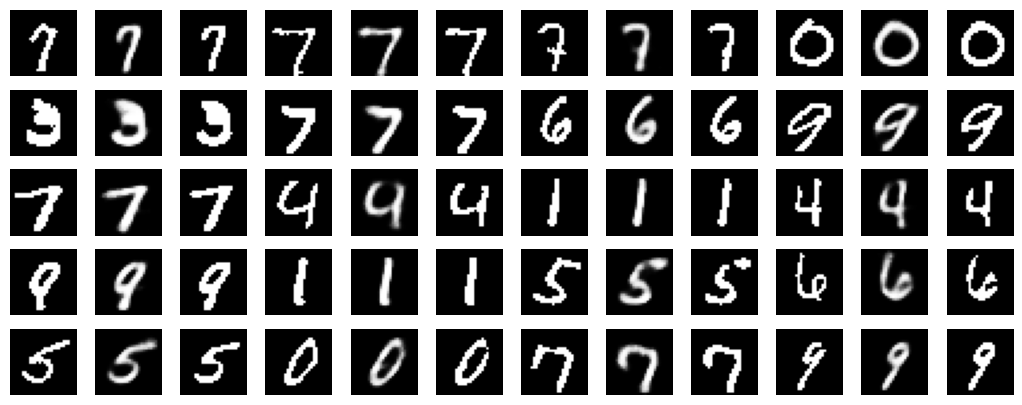

In [16]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_iaf.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_iaf.decode(model_vae_iaf.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [17]:
activeUnits(model_vae_iaf, trainImageData)

dim 0: Var_x[mu] = 36.672474  (active)
dim 1: Var_x[mu] = 3.502853  (active)
dim 2: Var_x[mu] = 42.426277  (active)
dim 3: Var_x[mu] = 42.258625  (active)
dim 4: Var_x[mu] = 14.906308  (active)
dim 5: Var_x[mu] = 25.456034  (active)
dim 6: Var_x[mu] = 11.488478  (active)
dim 7: Var_x[mu] = 9.593101  (active)
dim 8: Var_x[mu] = 20.794315  (active)
dim 9: Var_x[mu] = 0.312040  (active)
dim 10: Var_x[mu] = 3.482134  (active)
dim 11: Var_x[mu] = 7.190479  (active)
dim 12: Var_x[mu] = 4.691141  (active)
dim 13: Var_x[mu] = 4.396344  (active)
dim 14: Var_x[mu] = 8.734289  (active)
dim 15: Var_x[mu] = 4.955339  (active)
16/16 active units (threshold=0.01)


tensor([36.6725,  3.5029, 42.4263, 42.2586, 14.9063, 25.4560, 11.4885,  9.5931,
        20.7943,  0.3120,  3.4821,  7.1905,  4.6911,  4.3963,  8.7343,  4.9553])